In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl
import ast


df1 = pd.read_csv("/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/group-housed/behaviour_detection.csv")
df1["condition"] = 'grouped'

df2 = pd.read_csv("/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/socially-isolated/behaviour_detection.csv")
df2["condition"] = 'isolated'

df = pd.concat([df1, df2], ignore_index=True)  

interactions = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/clustered-interactions_pt2/cropped_interactions.csv')




In [2]:
## INTERACTIONS -> ONE ROW PER TRACK PER FRAME, THEN MERGE BEHAVIOUR (G and S only)

CONDITIONS = ['G', 'S']
KEEP = ['interaction_id', 'file', 'condition', 'Interaction Number',
        'interaction_type', 'Frame', 'Normalized Frame']

inter = interactions[interactions['condition'].isin(CONDITIONS)].copy()

# Interaction Pair = (Track_1 id, Track_2 id)
pair = inter['Interaction Pair'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
inter['track1_id'] = pair.str[0].astype(int)
inter['track2_id'] = pair.str[1].astype(int)

# explode: each interaction frame becomes two rows, one per larva
tracks = []
for t, other in [(1, 2), (2, 1)]:
    d = inter[KEEP].copy()
    d['track'] = t                             # which side of the pair (Track_1 / Track_2 columns)
    d['track_id'] = inter[f'track{t}_id']      # this larva's id
    d['partner_id'] = inter[f'track{other}_id']
    tracks.append(d)

inter_tracks = pd.concat(tracks, ignore_index=True)

# match file names: interactions have '.mp4', behaviour data doesn't
inter_tracks['file_key'] = inter_tracks['file'].str.replace('.mp4', '', regex=False)

# merge behaviour for that larva, in that video, on that frame
beh = df[['file', 'track_id', 'frame', 'behaviour']].rename(columns={'file': 'file_key', 'frame': 'Frame'})

inter_tracks = inter_tracks.merge(beh, on=['file_key', 'track_id', 'Frame'], how='left')
inter_tracks = inter_tracks.sort_values(['interaction_id', 'track', 'Frame']).reset_index(drop=True)

# sanity checks
print('rows expected / got:', 2 * len(inter), len(inter_tracks))
print('duplicate interaction/track/frame rows:', inter_tracks.duplicated(['interaction_id', 'track', 'Frame']).sum())
print('track_id == partner_id (should be 0):', (inter_tracks['track_id'] == inter_tracks['partner_id']).sum())
print('missing behaviour:', inter_tracks['behaviour'].isna().mean().round(4))


rows expected / got: 288078 288078
duplicate interaction/track/frame rows: 0
track_id == partner_id (should be 0): 0
missing behaviour: 0.0


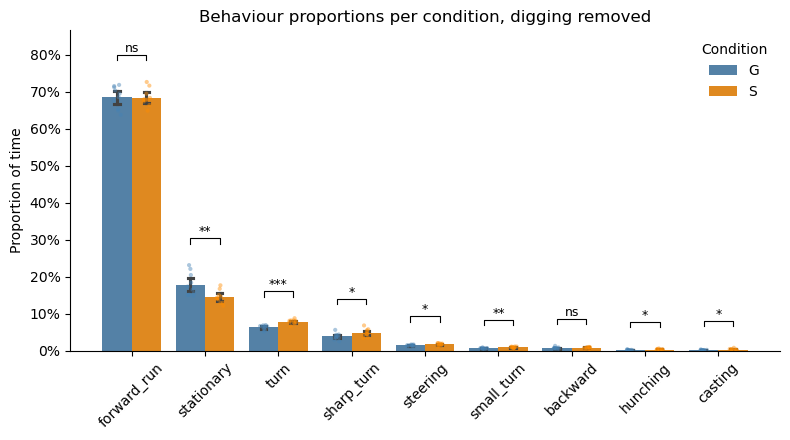

,condition,behaviour,mean_proportion,sem_proportion,mean_n_frames,n_recordings,p_value,significance
0,G,forward_run,0.684242,0.009325,10126.1,10,0.850107,ns
1,S,forward_run,0.684141,0.007295,9528.1,10,0.850107,ns
2,G,stationary,0.178935,0.009699,2665.3,10,0.004586,**
3,S,stationary,0.144753,0.005416,2016.2,10,0.004586,**
4,G,turn,0.063444,0.001916,942.4,10,0.000440,***
5,S,turn,0.078756,0.001875,1097.9,10,0.000440,***
6,G,sharp_turn,0.039088,0.002663,575.0,10,0.037635,*
7,S,sharp_turn,0.048746,0.003279,679.6,10,0.037635,*
8,G,steering,0.014860,0.000637,217.8,10,0.045155,*
9,S,steering,0.017767,0.000939,250.5,10,0.045155,*


In [4]:

HUE_ORDER = ['G', 'S']

PALETTE = {
    "G": 'steelblue',     
    "S": 'darkorange',}

import matplotlib.ticker as mtick
from scipy.stats import mannwhitneyu

# remove digging before calculating proportions of time
time_df = inter_tracks[inter_tracks["behaviour"] != "digging"].copy()

# total non-digging frames per recording
time_total_frames = (
    time_df.groupby(["file", "condition"])
    .size()
    .reset_index(name="total_frames")
)

# non-digging frames per behaviour per recording
time_behaviour_frames = (
    time_df.groupby(["file", "condition", "behaviour"])
    .size()
    .reset_index(name="n_frames")
)

# add zeros where a recording had no non-digging frames for a behaviour
behaviour_order = sorted(time_df["behaviour"].dropna().unique())
recordings = time_total_frames[["file", "condition", "total_frames"]].drop_duplicates().copy()
behaviours = pd.DataFrame({"behaviour": behaviour_order})
recordings["_key"] = 1
behaviours["_key"] = 1

behaviour_prop_stats = (
    recordings.merge(behaviours, on="_key")
    .drop(columns="_key")
    .merge(time_behaviour_frames, on=["file", "condition", "behaviour"], how="left")
)
behaviour_prop_stats["n_frames"] = behaviour_prop_stats["n_frames"].fillna(0)
behaviour_prop_stats["proportion"] = behaviour_prop_stats["n_frames"] / behaviour_prop_stats["total_frames"]

# order by mean proportion of time across recordings
behaviour_order = (
    behaviour_prop_stats.groupby("behaviour")["proportion"]
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)

condition_order = [c for c in HUE_ORDER if c in behaviour_prop_stats["condition"].unique()]
if len(condition_order) == 0:
    condition_order = sorted(behaviour_prop_stats["condition"].dropna().unique())

palette = PALETTE

def p_to_stars(p_value):
    if pd.isna(p_value):
        return "n/a"
    if p_value < 0.001:
        return "***"
    if p_value < 0.01:
        return "**"
    if p_value < 0.05:
        return "*"
    return "ns"

# Mann-Whitney U per behaviour, comparing per-recording proportions of time
stats_rows = []
if len(condition_order) == 2:
    condition_a, condition_b = condition_order
    for behaviour in behaviour_order:
        values_a = behaviour_prop_stats.loc[
            (behaviour_prop_stats["condition"] == condition_a)
            & (behaviour_prop_stats["behaviour"] == behaviour),
            "proportion",
        ]
        values_b = behaviour_prop_stats.loc[
            (behaviour_prop_stats["condition"] == condition_b)
            & (behaviour_prop_stats["behaviour"] == behaviour),
            "proportion",
        ]

        if len(values_a) > 0 and len(values_b) > 0:
            _, p_value = mannwhitneyu(values_a, values_b, alternative="two-sided")
        else:
            p_value = np.nan

        stats_rows.append({
            "behaviour": behaviour,
            f"n_{condition_a}": len(values_a),
            f"n_{condition_b}": len(values_b),
            "p_value": p_value,
            "significance": p_to_stars(p_value),
        })

stats_table = pd.DataFrame(stats_rows)

plt.figure(figsize=(8, 4.5))
ax = sns.barplot(
    data=behaviour_prop_stats,
    x="behaviour",
    y="proportion",
    hue="condition",
    order=behaviour_order,
    hue_order=condition_order,
    palette=palette,
    errorbar=("ci", 95),
    capsize=0.15,
)
sns.stripplot(
    data=behaviour_prop_stats,
    x="behaviour",
    y="proportion",
    hue="condition",
    order=behaviour_order,
    hue_order=condition_order,
    palette=palette,
    dodge=True,
    alpha=0.45,
    size=3,
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("Proportion of time")
ax.set_title("Behaviour proportions per condition, digging removed")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.tick_params(axis="x", rotation=45)

# add significance brackets
if len(condition_order) == 2 and not stats_table.empty:
    y_max = behaviour_prop_stats["proportion"].max()
    y_step = max(y_max * 0.08, 0.03)
    bracket_height = y_step * 0.25
    ax.set_ylim(0, y_max + y_step * 2.4)

    for x, behaviour in enumerate(behaviour_order):
        y = behaviour_prop_stats.loc[behaviour_prop_stats["behaviour"] == behaviour, "proportion"].max() + y_step
        label = stats_table.loc[stats_table["behaviour"] == behaviour, "significance"].iloc[0]
        x1, x2 = x - 0.2, x + 0.2
        ax.plot([x1, x1, x2, x2], [y, y + bracket_height, y + bracket_height, y], color="black", lw=0.8)
        ax.text(x, y + bracket_height, label, ha="center", va="bottom", fontsize=9)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:len(condition_order)], labels[:len(condition_order)], title="Condition", frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

summary_table = (
    behaviour_prop_stats.groupby(["condition", "behaviour"], as_index=False)
    .agg(
        mean_proportion=("proportion", "mean"),
        sem_proportion=("proportion", "sem"),
        mean_n_frames=("n_frames", "mean"),
        n_recordings=("file", "nunique"),
    )
)

if not stats_table.empty:
    summary_table = summary_table.merge(
        stats_table[["behaviour", "p_value", "significance"]],
        on="behaviour",
        how="left",
    )

summary_table["behaviour"] = pd.Categorical(summary_table["behaviour"], categories=behaviour_order, ordered=True)
summary_table["condition"] = pd.Categorical(summary_table["condition"], categories=condition_order, ordered=True)
summary_table = summary_table.sort_values(["behaviour", "condition"]).reset_index(drop=True)

display(summary_table)


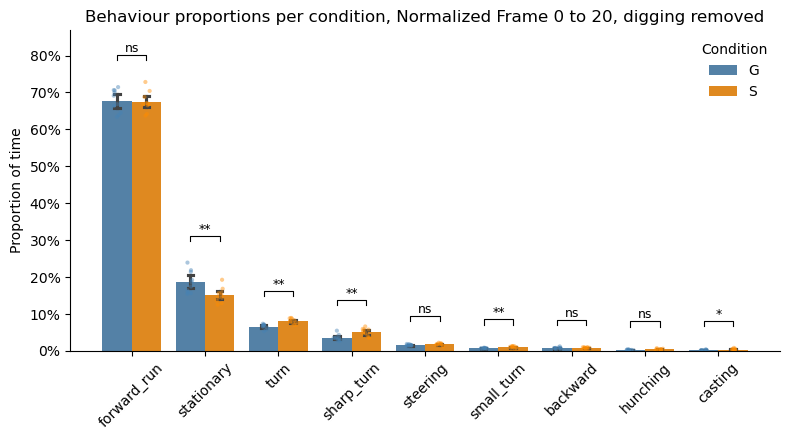

,condition,behaviour,mean_proportion,sem_proportion,mean_n_frames,n_recordings,p_value,significance
0,G,forward_run,0.676672,0.009637,5241.7,10,0.850107,ns
1,S,forward_run,0.674201,0.008570,4918.0,10,0.850107,ns
2,G,stationary,0.185948,0.009404,1450.9,10,0.007285,**
3,S,stationary,0.150579,0.006302,1099.6,10,0.007285,**
4,G,turn,0.066093,0.002052,515.1,10,0.001008,**
5,S,turn,0.080214,0.002225,585.6,10,0.001008,**
6,G,sharp_turn,0.035767,0.002628,276.4,10,0.003611,**
7,S,sharp_turn,0.050649,0.003280,370.2,10,0.003611,**
8,G,steering,0.015798,0.000657,121.9,10,0.088973,ns
9,S,steering,0.017827,0.000959,131.7,10,0.088973,ns


In [6]:

HUE_ORDER = ['G', 'S']

PALETTE = {
    "G": 'steelblue',     
    "S": 'darkorange',}

import matplotlib.ticker as mtick
from scipy.stats import mannwhitneyu

# remove digging before calculating proportions of time
# keep only Normalized Frame 0 to 10 (inclusive)
FRAME_MIN, FRAME_MAX = 0, 20
time_df = inter_tracks[
    inter_tracks["Normalized Frame"].between(FRAME_MIN, FRAME_MAX)
    & (inter_tracks["behaviour"] != "digging")
].copy()

# total non-digging frames per recording
time_total_frames = (
    time_df.groupby(["file", "condition"])
    .size()
    .reset_index(name="total_frames")
)

# non-digging frames per behaviour per recording
time_behaviour_frames = (
    time_df.groupby(["file", "condition", "behaviour"])
    .size()
    .reset_index(name="n_frames")
)

# add zeros where a recording had no non-digging frames for a behaviour
behaviour_order = sorted(time_df["behaviour"].dropna().unique())
recordings = time_total_frames[["file", "condition", "total_frames"]].drop_duplicates().copy()
behaviours = pd.DataFrame({"behaviour": behaviour_order})
recordings["_key"] = 1
behaviours["_key"] = 1

behaviour_prop_stats = (
    recordings.merge(behaviours, on="_key")
    .drop(columns="_key")
    .merge(time_behaviour_frames, on=["file", "condition", "behaviour"], how="left")
)
behaviour_prop_stats["n_frames"] = behaviour_prop_stats["n_frames"].fillna(0)
behaviour_prop_stats["proportion"] = behaviour_prop_stats["n_frames"] / behaviour_prop_stats["total_frames"]

# order by mean proportion of time across recordings
behaviour_order = (
    behaviour_prop_stats.groupby("behaviour")["proportion"]
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)

condition_order = [c for c in HUE_ORDER if c in behaviour_prop_stats["condition"].unique()]
if len(condition_order) == 0:
    condition_order = sorted(behaviour_prop_stats["condition"].dropna().unique())

palette = PALETTE

def p_to_stars(p_value):
    if pd.isna(p_value):
        return "n/a"
    if p_value < 0.001:
        return "***"
    if p_value < 0.01:
        return "**"
    if p_value < 0.05:
        return "*"
    return "ns"

# Mann-Whitney U per behaviour, comparing per-recording proportions of time
stats_rows = []
if len(condition_order) == 2:
    condition_a, condition_b = condition_order
    for behaviour in behaviour_order:
        values_a = behaviour_prop_stats.loc[
            (behaviour_prop_stats["condition"] == condition_a)
            & (behaviour_prop_stats["behaviour"] == behaviour),
            "proportion",
        ]
        values_b = behaviour_prop_stats.loc[
            (behaviour_prop_stats["condition"] == condition_b)
            & (behaviour_prop_stats["behaviour"] == behaviour),
            "proportion",
        ]

        if len(values_a) > 0 and len(values_b) > 0:
            _, p_value = mannwhitneyu(values_a, values_b, alternative="two-sided")
        else:
            p_value = np.nan

        stats_rows.append({
            "behaviour": behaviour,
            f"n_{condition_a}": len(values_a),
            f"n_{condition_b}": len(values_b),
            "p_value": p_value,
            "significance": p_to_stars(p_value),
        })

stats_table = pd.DataFrame(stats_rows)

plt.figure(figsize=(8, 4.5))
ax = sns.barplot(
    data=behaviour_prop_stats,
    x="behaviour",
    y="proportion",
    hue="condition",
    order=behaviour_order,
    hue_order=condition_order,
    palette=palette,
    errorbar=("ci", 95),
    capsize=0.15,
)
sns.stripplot(
    data=behaviour_prop_stats,
    x="behaviour",
    y="proportion",
    hue="condition",
    order=behaviour_order,
    hue_order=condition_order,
    palette=palette,
    dodge=True,
    alpha=0.45,
    size=3,
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("Proportion of time")
ax.set_title(f"Behaviour proportions per condition, Normalized Frame {FRAME_MIN} to {FRAME_MAX}, digging removed")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.tick_params(axis="x", rotation=45)

# add significance brackets
if len(condition_order) == 2 and not stats_table.empty:
    y_max = behaviour_prop_stats["proportion"].max()
    y_step = max(y_max * 0.08, 0.03)
    bracket_height = y_step * 0.25
    ax.set_ylim(0, y_max + y_step * 2.4)

    for x, behaviour in enumerate(behaviour_order):
        y = behaviour_prop_stats.loc[behaviour_prop_stats["behaviour"] == behaviour, "proportion"].max() + y_step
        label = stats_table.loc[stats_table["behaviour"] == behaviour, "significance"].iloc[0]
        x1, x2 = x - 0.2, x + 0.2
        ax.plot([x1, x1, x2, x2], [y, y + bracket_height, y + bracket_height, y], color="black", lw=0.8)
        ax.text(x, y + bracket_height, label, ha="center", va="bottom", fontsize=9)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:len(condition_order)], labels[:len(condition_order)], title="Condition", frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

summary_table = (
    behaviour_prop_stats.groupby(["condition", "behaviour"], as_index=False)
    .agg(
        mean_proportion=("proportion", "mean"),
        sem_proportion=("proportion", "sem"),
        mean_n_frames=("n_frames", "mean"),
        n_recordings=("file", "nunique"),
    )
)

if not stats_table.empty:
    summary_table = summary_table.merge(
        stats_table[["behaviour", "p_value", "significance"]],
        on="behaviour",
        how="left",
    )

summary_table["behaviour"] = pd.Categorical(summary_table["behaviour"], categories=behaviour_order, ordered=True)
summary_table["condition"] = pd.Categorical(summary_table["condition"], categories=condition_order, ordered=True)
summary_table = summary_table.sort_values(["behaviour", "condition"]).reset_index(drop=True)

display(summary_table)
